# N-Queens SAT Encodings Benchmark Analysis

Notebook này phân tích và trực quan hóa kết quả đo lường hiệu năng của 5 phương pháp mã hóa SAT cho bài toán N-Queens:
1. Binomial Encoding (`binomial.py`)
2. Binary Encoding (`binary.py`)
3. Commander Encoding (`commander.py`)
4. Product Encoding (`product.py`)
5. Sequential Counter Encoding (`sequential.py`)

Dữ liệu được nạp trực tiếp từ file `benchmark_results.csv` sinh ra bởi `playground.py`.

In [2]:
import csv
import os
import matplotlib.pyplot as plt

# Hiển thị biểu đồ trực tiếp bên trong notebook
%matplotlib inline

# Cấu hình màu sắc và ký hiệu đồng bộ cho từng phương pháp
STYLE_CONFIG = {
    "Binomial": {"color": "#E63946", "marker": "o", "linestyle": "-"},
    "Binary": {"color": "#F4A261", "marker": "s", "linestyle": "-"},
    "Commander": {"color": "#2A9D8F", "marker": "^", "linestyle": "-"},
    "Product": {"color": "#9B5DE5", "marker": "D", "linestyle": "-"},
    "Sequential": {"color": "#1D3557", "marker": "v", "linestyle": "-"},
}

CSV_FILE = "benchmark_results.csv"

## 1. Đọc và Kiểm tra Dữ liệu Thực nghiệm

In [3]:
data = {}
all_n = set()

with open(CSV_FILE, mode="r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    print(f"{'N':<5} | {'Encoding':<12} | {'Status':<6} | {'Variables':<10} | {'Clauses':<10} | {'Time (s)':<10}")
    print("-" * 68)
    for row in reader:
        if row.get("Status") != "SAT":
            continue
        n = int(row["N"])
        enc = row["Encoding"]
        v = int(row["Variables"])
        c = int(row["Clauses"])
        t = float(row["Time_Seconds"])
        
        all_n.add(n)
        if enc not in data:
            data[enc] = {"n": [], "time": [], "vars": [], "clauses": []}
        data[enc]["n"].append(n)
        data[enc]["time"].append(t)
        data[enc]["vars"].append(v)
        data[enc]["clauses"].append(c)
        
        print(f"{n:<5} | {enc:<12} | {'SAT':<6} | {v:<10} | {c:<10} | {t:<10.6f}")

all_n = sorted(list(all_n))
print(f"\n[OK] Danh sach cac kich thuoc N: {all_n}")

N     | Encoding     | Status | Variables  | Clauses    | Time (s)  
--------------------------------------------------------------------
4     | Binomial     | SAT    | 16         | 84         | 0.000244  
4     | Binary       | SAT    | 48         | 120        | 0.000215  
4     | Commander    | SAT    | 16         | 84         | 0.000124  
4     | Product      | SAT    | 56         | 124        | 0.000186  
4     | Sequential   | SAT    | 58         | 116        | 0.000171  
8     | Binomial     | SAT    | 64         | 744        | 0.000919  
8     | Binary       | SAT    | 174        | 728        | 0.000740  
8     | Commander    | SAT    | 146        | 618        | 0.000850  
8     | Product      | SAT    | 252        | 668        | 0.000849  
8     | Sequential   | SAT    | 274        | 604        | 0.000776  
16    | Binomial     | SAT    | 256        | 6352       | 0.007022  
16    | Binary       | SAT    | 572        | 3928       | 0.004860  
16    | Commander    | SAT    | 52

## 2. Biểu đồ Thời gian Giải (Solving Time vs N)
So sánh tốc độ tìm kiếm nghiệm thỏa mãn (SAT) giữa các phương pháp trên thang đo logarit.

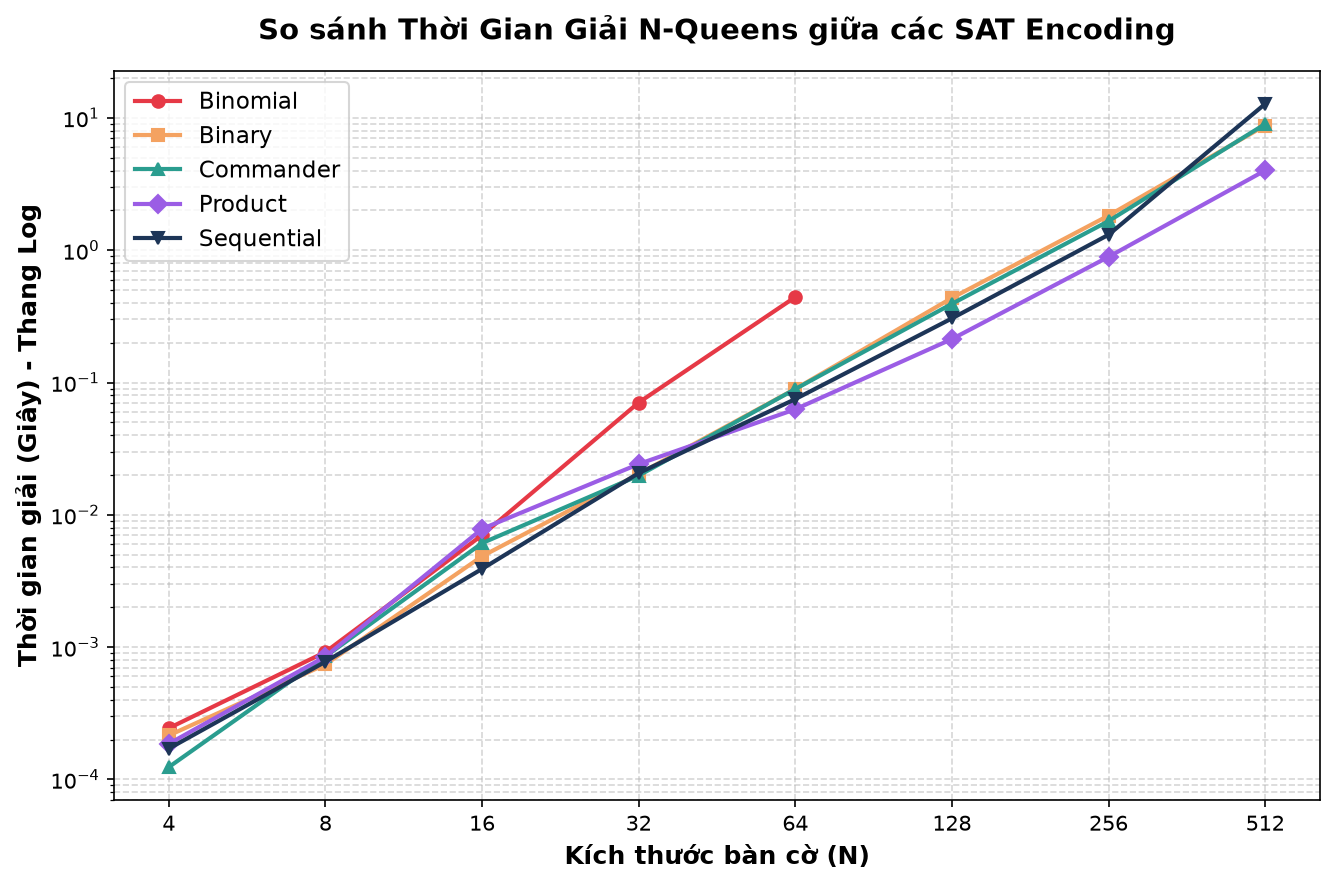

In [4]:
plt.figure(figsize=(9, 6), dpi=150)
for enc, values in data.items():
    cfg = STYLE_CONFIG.get(enc, {})
    plt.plot(values["n"], values["time"], label=enc, linewidth=2, **cfg)

plt.xlabel("Kích thước bàn cờ (N)", fontsize=12, fontweight="bold")
plt.ylabel("Thời gian giải (Giây) - Thang Log", fontsize=12, fontweight="bold")
plt.title("So sánh Thời Gian Giải N-Queens giữa các SAT Encoding", fontsize=14, fontweight="bold", pad=15)
plt.xscale("log", base=2)
plt.yscale("log")
plt.xticks(all_n, [str(x) for x in all_n])
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(fontsize=11, loc="upper left")
plt.tight_layout()
plt.show()

## 3. Biểu đồ Số lượng Mệnh đề (Clauses vs N)
Thể hiện sự khác biệt giữa phương pháp bùng nổ bậc 3 $O(N^3)$ (Binomial) và các phương pháp tuyến tính $O(N)$ (Product, Sequential, Commander).

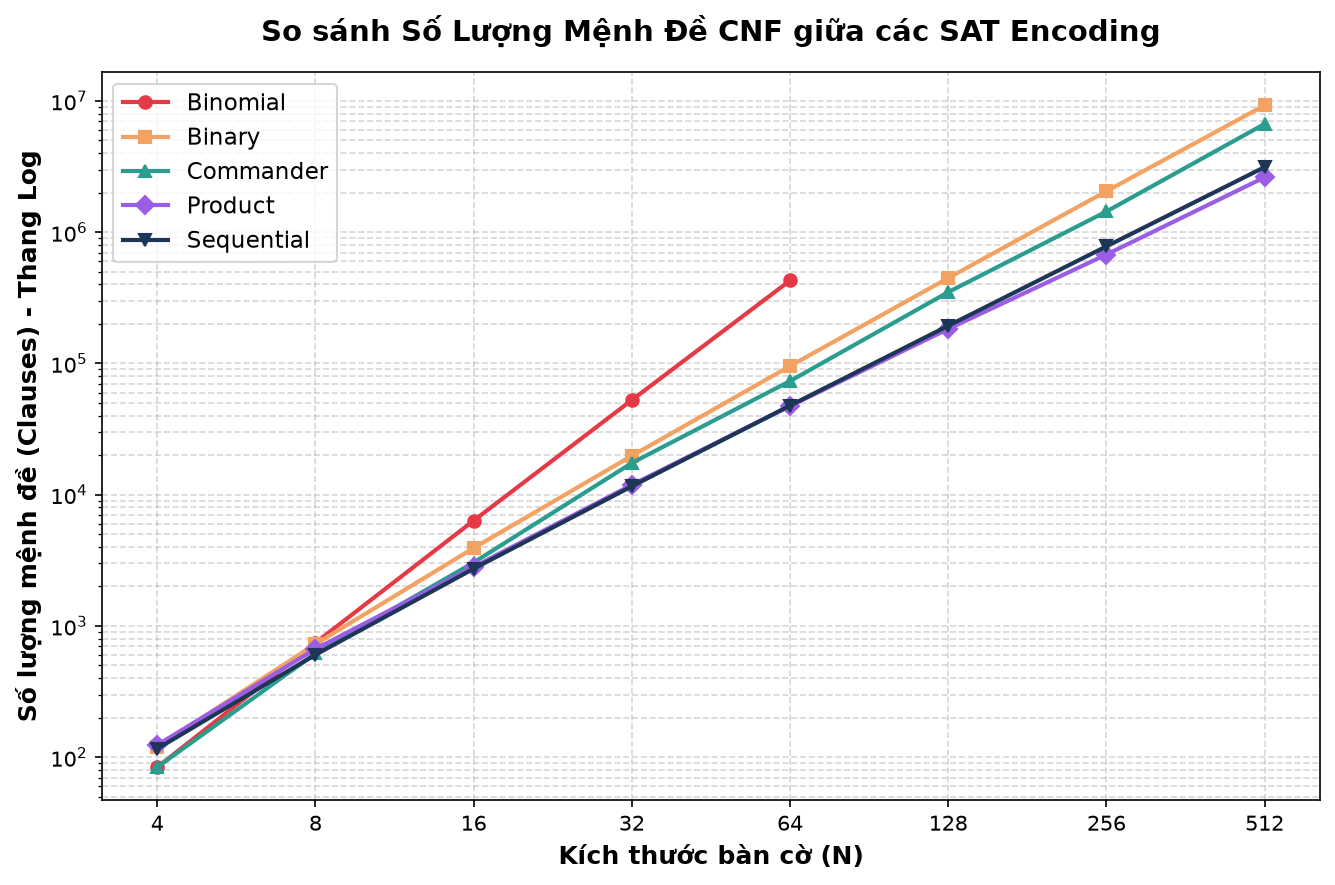

In [5]:
plt.figure(figsize=(9, 6), dpi=150)
for enc, values in data.items():
    cfg = STYLE_CONFIG.get(enc, {})
    plt.plot(values["n"], values["clauses"], label=enc, linewidth=2, **cfg)

plt.xlabel("Kích thước bàn cờ (N)", fontsize=12, fontweight="bold")
plt.ylabel("Số lượng mệnh đề (Clauses) - Thang Log", fontsize=12, fontweight="bold")
plt.title("So sánh Số Lượng Mệnh Đề CNF giữa các SAT Encoding", fontsize=14, fontweight="bold", pad=15)
plt.xscale("log", base=2)
plt.yscale("log")
plt.xticks(all_n, [str(x) for x in all_n])
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(fontsize=11, loc="upper left")
plt.tight_layout()
plt.show()

## 4. Biểu đồ Số lượng Biến Logic (Variables vs N)
So sánh số lượng biến phụ (Auxiliary Variables) được đưa vào bởi từng kỹ thuật:

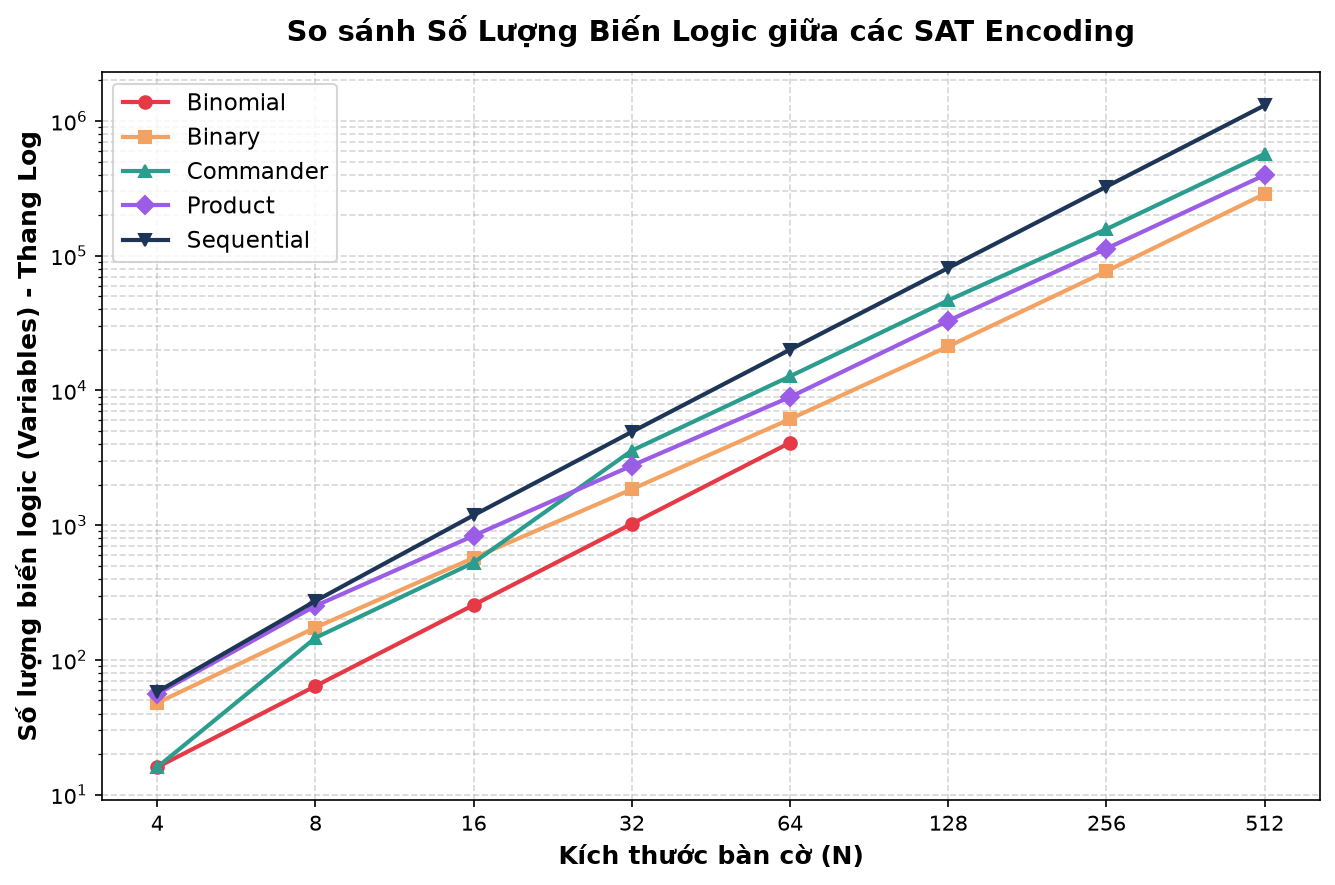

In [6]:
plt.figure(figsize=(9, 6), dpi=150)
for enc, values in data.items():
    cfg = STYLE_CONFIG.get(enc, {})
    plt.plot(values["n"], values["vars"], label=enc, linewidth=2, **cfg)

plt.xlabel("Kích thước bàn cờ (N)", fontsize=12, fontweight="bold")
plt.ylabel("Số lượng biến logic (Variables) - Thang Log", fontsize=12, fontweight="bold")
plt.title("So sánh Số Lượng Biến Logic giữa các SAT Encoding", fontsize=14, fontweight="bold", pad=15)
plt.xscale("log", base=2)
plt.yscale("log")
plt.xticks(all_n, [str(x) for x in all_n])
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(fontsize=11, loc="upper left")
plt.tight_layout()
plt.show()